Scale -10.0: P2V error: 34.636787511710644 rad, 5.512615945312379 waves, defocus distance: -69974.54194826208 microns
Distance list : [OldStyleField(-69974.54194826)]
Scale 7.777777777777778: P2V error: 26.93972362021939 rad, 4.287590179687406 waves, defocus distance: 54424.64373753718 microns
Distance list : [OldStyleField(-69974.54194826), OldStyleField(54424.64373754)]
Distance List: [OldStyleField(-69974.54194826), OldStyleField(54424.64373754)]
DX List: [2.0071, 2.0071]
(1024, 1024)


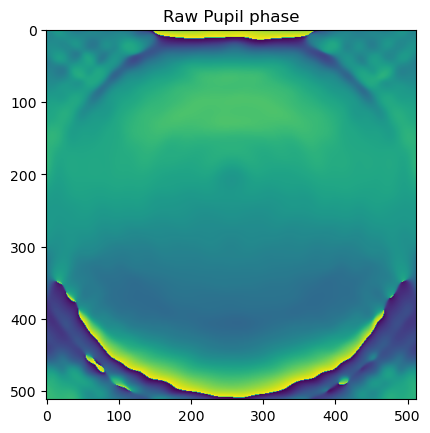

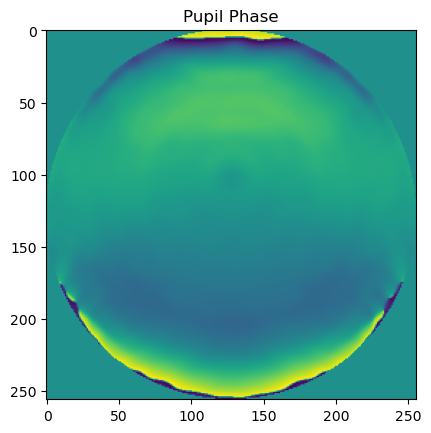

P2V error of pupil phase: 5.9975693639286
(512, 512)


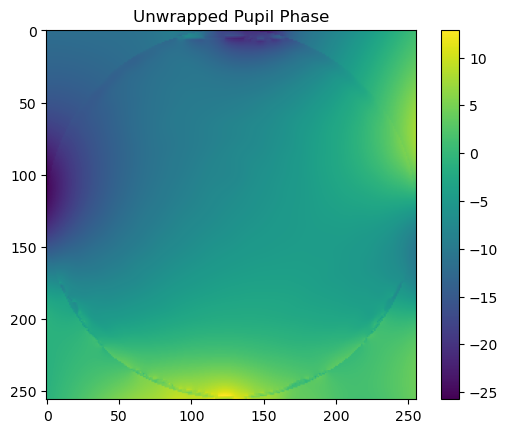

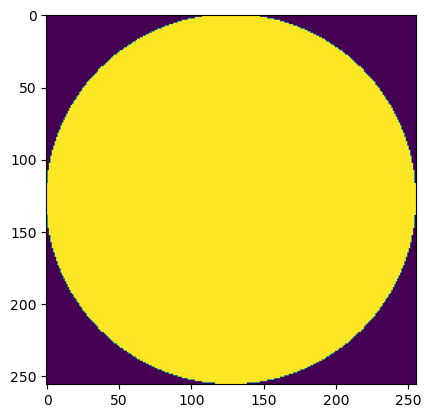

(512, 512)


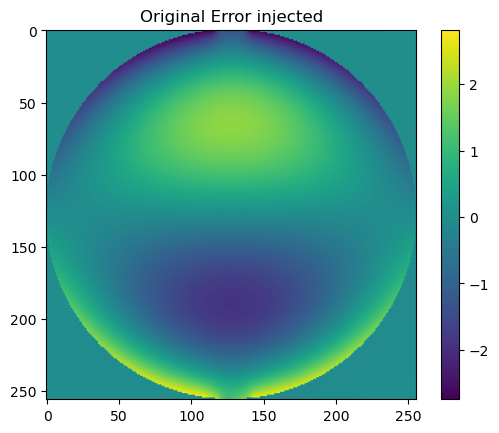

P2V of Original injected error: 5.616701452678232


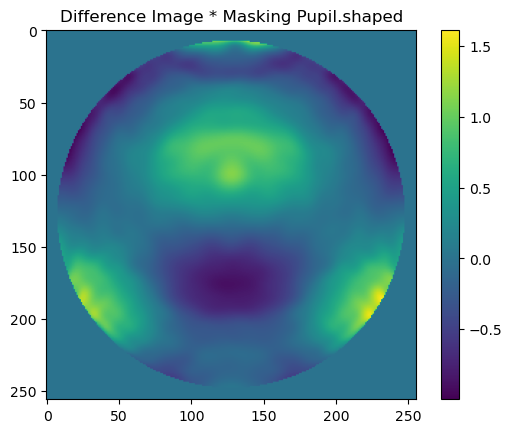

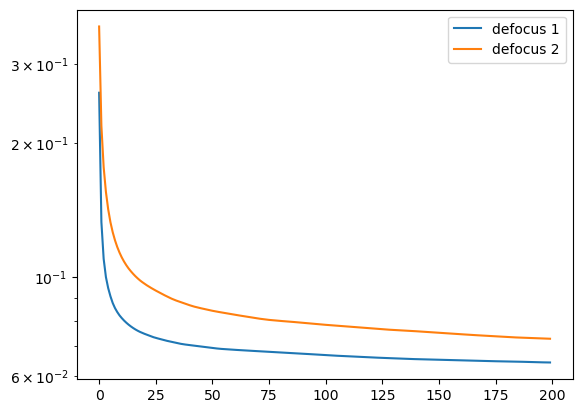

Median error in nanometers: -2.2064084232789747 nm
RMS error of Check_error_region:49.29974112206806 Nanometers
RMS error of check_error_region: 0.4765529370245158 radians
Scale -10.0: P2V error: 34.636787511710644 rad, 5.512615945312379 waves, defocus distance: -69974.54194826208 microns
Distance list : [OldStyleField(-69974.54194826)]
Scale 8.055555555555555: P2V error: 27.901856606655794 rad, 4.440718400390527 waves, defocus distance: 56368.38101387779 microns
Distance list : [OldStyleField(-69974.54194826), OldStyleField(56368.38101388)]
Distance List: [OldStyleField(-69974.54194826), OldStyleField(56368.38101388)]
DX List: [2.0071, 2.0071]
(1024, 1024)


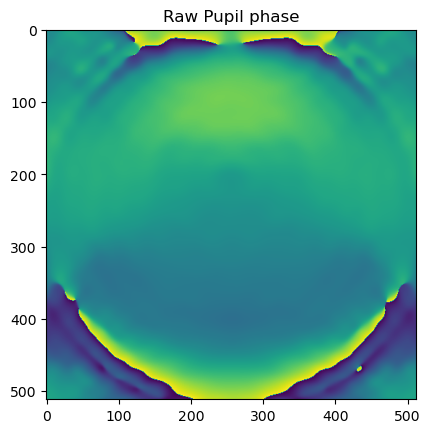

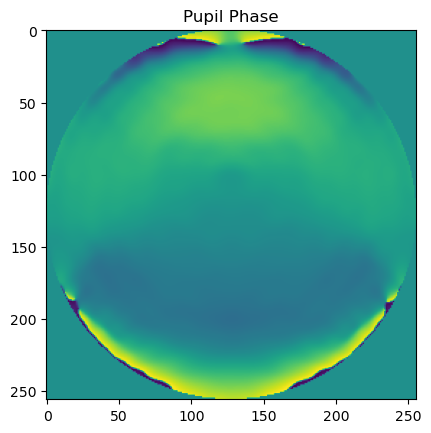

P2V error of pupil phase: 6.052060393288823
(512, 512)


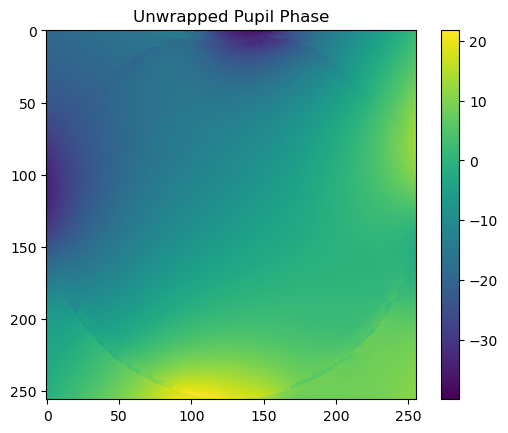

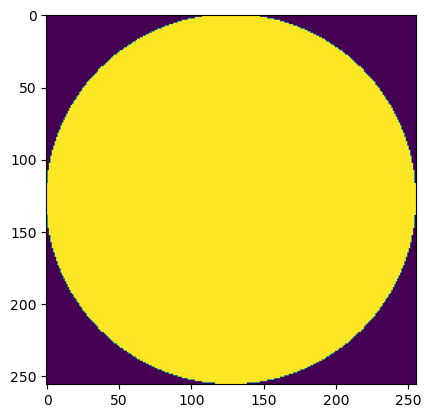

(512, 512)


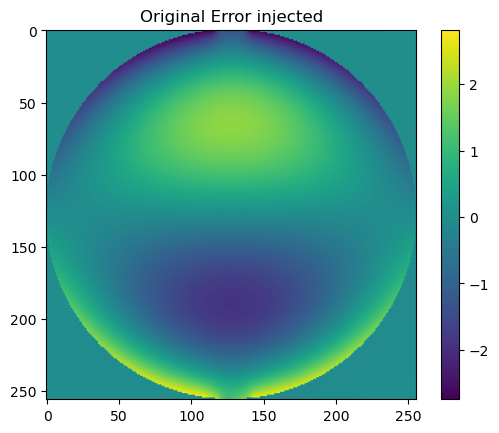

P2V of Original injected error: 5.616701452678232


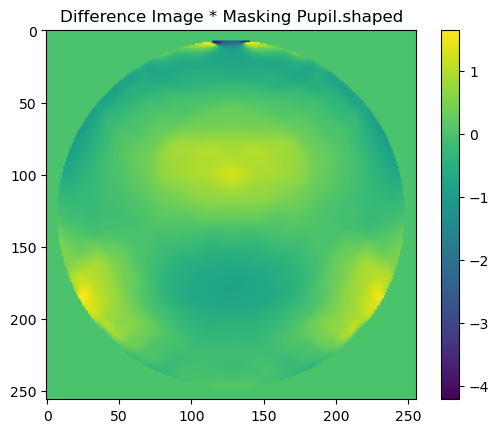

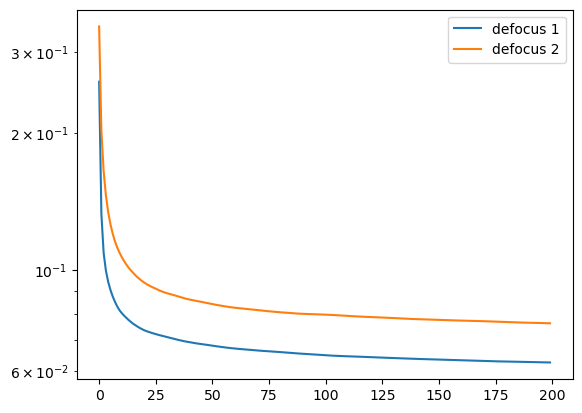

Median error in nanometers: -3.650103799417452 nm
RMS error of Check_error_region:51.83871685689821 Nanometers
RMS error of check_error_region: 0.5010957909204701 radians
Scale -10.0: P2V error: 34.636787511710644 rad, 5.512615945312379 waves, defocus distance: -69974.54194826208 microns
Distance list : [OldStyleField(-69974.54194826)]
Scale 8.333333333333334: P2V error: 28.863989593092203 rad, 4.593846621093649 waves, defocus distance: 58312.1182902184 microns
Distance list : [OldStyleField(-69974.54194826), OldStyleField(58312.11829022)]
Distance List: [OldStyleField(-69974.54194826), OldStyleField(58312.11829022)]
DX List: [2.0071, 2.0071]


KeyboardInterrupt: 

In [1]:
from hcipy import *
import numpy as np
import matplotlib.pyplot as plt
from image_sharpening import FocusDiversePhaseRetrieval, ft_rev, mft_rev, InstrumentConfiguration
from skimage.transform import resize
from processing import phase_unwrap_2d


# Constants for system setup (pupil size, focal length, wavelength, etc.)
pupil_size = 10.12e-3
small_pupil_size = 9.5e-3 
focal_length = 500e-3
wavelength = 650e-9
grid_size = 256
q = 16
num_airy = 16
f = focal_length
D = pupil_size
seal_params = {'image_dx': 2.0071, # 
               'efl': focal_length*1e3, # SEAL effective focal length, mm
               'wavelength': 0.65, # SEAL center wavelength, microns
                'pupil_size': pupil_size*1e3, # Keck entrance pupil diameter
                    }
conf = InstrumentConfiguration(seal_params)

# Create a pupil grid with the specified size and pupil diameter
pupil_grid = make_pupil_grid(256, pupil_size)

# Create a focal grid based on system parameters
focal_grid = make_focal_grid(q=q, num_airy=num_airy, pupil_diameter=pupil_size, focal_length=focal_length, reference_wavelength=wavelength)

# Setup apertures for telescope and masking pupils
aperture = make_circular_aperture(pupil_size)
telescope_pupil = aperture(pupil_grid)
small_aperture = make_circular_aperture(small_pupil_size)
masking_pupil = small_aperture(pupil_grid)

# Convert phase into meters using the wavelength
def phase_to_m(phase, wv):
    return phase * wv / (2 * np.pi)

# Calculate defocus distance from peak-to-valley (P2V) error in meters
def p_to_delta(P, f, D):
    return 8 * P * (f/D)**2

# Convert defocus distance into phase error
def delta_to_p(delta, f, D):
    return -1 * delta / (8 * (f/D)**2)

# Function to propagate the wavefront from pupil to focal plane and return focal intensity
def propagate_image(defocus_phase, test_ab, telescope_pupil, wavelength):
    # Set up the propagator to simulate wavefront propagation
    prop_p2f = FraunhoferPropagator(pupil_grid, focal_grid, focal_length=focal_length)
    # Combine the test aberration and defocus phase
    combined_phase = (test_ab + defocus_phase).ravel() 
    # Apply the phase to the telescope pupil
    pupil_field = telescope_pupil * np.exp(1j * combined_phase)
    # Create a wavefront object
    wavefront = Wavefront(pupil_field, wavelength)
    # Propagate the wavefront to the focal plane
    focal_field = prop_p2f.forward(wavefront)
    # Calculate the intensity of the focal plane image
    focal_intensity = np.abs(focal_field.electric_field.reshape(focal_grid.shape))**2
    return focal_intensity

# Function to calculate P2V error and defocus distance for a given defocus phase and scaling factor
def calculate_defocus_params(example_defocus, scale, f, D):
    defocus_phase = example_defocus * scale
    p2v_radians = np.max(defocus_phase) - np.min(defocus_phase)
    p2v_m = phase_to_m(p2v_radians, 650e-9)
    delta = p_to_delta(p2v_m, f, D)
    delta = delta if scale > 0 else -1 * delta
    return p2v_radians, delta

# Generate PSFs for different defocus scales and calculate associated defocus distances
def generate_defocus_lists(example_defocus, scales, f, D, test_ab, telescope_pupil, wavelength):
    psf_list = []
    distance_list = []
    dx_list = [2.0071] * len(scales)

    # Ensure defocus and test aberration have compatible shapes
    example_defocus = example_defocus.reshape(telescope_pupil.shape)
    test_ab = test_ab.reshape(telescope_pupil.shape)

    # Calculate the PSF without defocus (reference)
    no_defocus_phase = np.zeros_like(example_defocus)
    no_defocus_image = propagate_image(no_defocus_phase, test_ab, telescope_pupil, wavelength)
    psf_list.append(no_defocus_image)

    # Loop over the scales to generate PSFs for different defocus values
    for scale in scales:
        p2v_radians, delta = calculate_defocus_params(example_defocus, scale, f, D)
        print(f'Scale {scale}: P2V error: {p2v_radians} rad, {p2v_radians/(2*np.pi)} waves, defocus distance: {delta*1e6} microns')
        defocus_image = propagate_image(example_defocus * scale, test_ab, telescope_pupil, wavelength)
        psf_list.append(defocus_image)
        distance_list.append(delta * 1e6)  # Defocus distance in microns
        print(f'Distance list : {distance_list}')

    return psf_list, distance_list, dx_list

# Main function to run the focus diverse phase retrieval process
#Quiet or verbose -- look up
#zap debugging
def run_focus_diverse_phase_retrieval_v2(scales, test_ab_scale):
    # Define constants for this run
    pupil_size = 10.12e-3
    small_pupil_size = 9.5e-3 
    focal_length = 500e-3
    wavelength = 650e-9
    grid_size = 256
    q = 16
    num_airy = 16
    f = focal_length
    D = pupil_size
    dx_list = [2.0071] * len(scales)

    # Set up pupil and focal grids
    pupil_grid = make_pupil_grid(256, pupil_size)
    focal_grid = make_focal_grid(q=q, num_airy=num_airy, pupil_diameter=pupil_size, focal_length=focal_length, reference_wavelength=wavelength)

    # Setup telescope and masking apertures
    aperture = make_circular_aperture(pupil_size)
    telescope_pupil = aperture(pupil_grid)
    small_aperture = make_circular_aperture(small_pupil_size)
    masking_pupil = small_aperture(pupil_grid)

    # Create initial wavefront
    wavefront = Wavefront(telescope_pupil, wavelength=wavelength)
    prop_p2f = FraunhoferPropagator(pupil_grid, focal_grid, focal_length=focal_length)
    pupil_image = wavefront.copy()

    # Generate Zernike polynomials for test aberrations and defocus
    influence_functions = make_zernike_basis(256, pupil_size, pupil_grid)
    test_ab = test_ab_scale * influence_functions[6]
    example_defocus = influence_functions[3].shaped

    # Generate PSFs and defocus distances for different scales
    psf_list, distance_list, dx_list = generate_defocus_lists(example_defocus, scales, f, D, test_ab, telescope_pupil, wavelength)
    #for i, psf in enumerate(psf_list):
        #print(f"PSF {i} shape: {psf.shape}, max: {np.max(psf)}, min: {np.min(psf)}")
    
    # Output the lists
    #print("PSF List", psf_list)
    print("Distance List:", distance_list)
    print("DX List:", dx_list)
    #defocus_images(psf_list)
    
    # Initialize the focus diverse phase retrieval process
    mp = FocusDiversePhaseRetrieval(psf_list,650e-3, dx_list, distance_list,phase_guess=np.zeros_like(psf_list[0]))
    for i in range(200):
        psf00 = mp.step() 
    # Configure instrument
    seal_params = {'image_dx': 2.0071, # 
               'efl': focal_length*1e3, # SEAL effective focal length, mm
               'wavelength': 0.65, # SEAL center wavelength, microns
                'pupil_size': pupil_size*1e3, # Keck entrance pupil diameter
                    }
    conf = InstrumentConfiguration(seal_params)
    
    #Plot the Phase in focal plane
    #plt.imshow(np.angle(psf00))
    #plt.title(f'Phase in focal plane')
    #plt.show()
    
    #Unwrap the phase and Plot unwrapped phase
    unwrapped_psf00 = phase_unwrap_2d(np.angle(psf00))
    #plt.imshow(unwrapped_psf00)
    #plt.colorbar()
    #plt.title("Unwrapped Phase of PSF00")
    #plt.show()
                                      
    #Retrieve raw pupil phase
    raw_pupil_phase = np.angle(mft_rev(psf00, conf))
    plt.imshow(raw_pupil_phase)
    plt.title(f'Raw Pupil phase')
    plt.show()
    
    #Resize and visualize the pupil phase
    pupil_phase = resize(raw_pupil_phase, (256, 256)) * telescope_pupil.shaped
    plt.imshow(pupil_phase)
    plt.title(f'Pupil Phase')
    plt.show()
    print(f'P2V error of pupil phase: {np.max(pupil_phase) - np.min(pupil_phase)}')
                             
    #Unwrap the pupil phase, thought it could be interesting
    unwrapped_pupil_phase = phase_unwrap_2d(pupil_phase)
    plt.imshow(unwrapped_pupil_phase)  # Unwrapped pupil plane phase
    plt.colorbar()
    plt.title("Unwrapped Pupil Phase")
    plt.show()
    print()

    # Plot the intensity for PSF (Focal Plane), debugging to ensure that we at least have a psf00
    intensity_psf00 = np.abs(psf00)**2
    #plt.imshow(intensity_psf00)  # Intensity in focal plane
    #plt.colorbar()
    #plt.title("Intensity of PSF00 (Focal Plane)")
    #plt.show()
    
    #Debugging to ensure we have a decent pupil
    plt.imshow(telescope_pupil.shaped)
    plt.show()
    plt.title(f'Telescope_pupil.shaped')
    
    #Comparing to Original Error
    pupil_image.electric_field = np.exp(complex(0, 1)*telescope_pupil*(test_ab))
    plt.imshow(phase_unwrap_2d(pupil_image.phase.shaped))
    plt.colorbar()
    plt.title(f'Original Error injected')
    plt.show()
    print(f'P2V of Original injected error: {np.max(pupil_image.phase.shaped) - np.min(pupil_image.phase.shaped)}')

    # Subtract median and calculate difference image
    med_subtracted = pupil_phase - np.median(pupil_phase[np.array(masking_pupil.shaped, dtype=bool)])
    difference_image = pupil_image.phase.shaped - med_subtracted#Masking pupil
    plt.imshow(difference_image * masking_pupil.shaped)
    plt.colorbar()
    plt.title(f'Difference Image * Masking Pupil.shaped')
    plt.show()
    
    #Graphing the Cost Functions, make it iterative, for i in range len[mp.cost_func]
    for i in range(len(mp.cost_functions)):
        plt.semilogy(mp.cost_functions[i], label=f'defocus {i+1}')
        
    plt.legend()
    plt.show()
    #plt.semilogy(mp.cost_functions[0], label='defocus 1', color='cyan')
    #plt.semilogy(mp.cost_functions[1], label='defocus 2', color='grey')
    #Calculate median error
    check_error_region = (pupil_image.phase.shaped - med_subtracted)[np.array(masking_pupil.shaped, dtype=bool)]
    nm_med = phase_to_m(np.median(check_error_region), 650e-9) * 1e9
    print(f'Median error in nanometers: {nm_med} nm')

    #If statement to shape the telescope pupil
    if telescope_pupil.ndim == 1:
        telescope_pupil = telescope_pupil.reshape(pupil_phase.shape)
    

    #Calculate RMS error ; convert to nano
    rms_error = np.sqrt(np.mean((check_error_region) ** 2))
    rms_nm= phase_to_m(rms_error, 650e-9)*1e9
    print(f"RMS error of Check_error_region:{rms_nm} Nanometers")
    print(f"RMS error of check_error_region: {rms_error} radians")

    # Return the results
    return {"distance_list":distance_list, "pupil_phase": pupil_phase, "difference_image": difference_image, "psf_list": psf_list, "p2v_error": np.max(pupil_phase) - np.min(pupil_phase), "rms_error_nm": rms_nm, "nm_med": nm_med}

# Function to visualize defocus images
#def defocus_images(psf_list):
    #for i, psf in enumerate(psf_list):
        #plt.figure()
        #plt.imshow(np.log10(psf / psf.max()), vmin=-5)
        #plt.colorbar()
        #plt.title(f'Focal Image {i}')
        #plt.show()

# Call the main function, assign scale  
#scales = [10,10]#Keep in mind larger scales will have negative impact on the phase unwrapping
test_ab_scale = 1
dim = 10
x_wise = np.linspace(-10,-7.5, dim)
y_wise = np.linspace(7.5,10, dim)
# Get the indices for the upper triangle of a 10x10 grid, excluding the diagonal
# This will give pairs of indices that correspond to the upper triangle of a matrix
upper_triangle = np.triu_indices(dim, 1)
#Create a list of pairs of indices corresponding to the upper triangle, 
#The result is a list of lists where each sublist is a pair of indices [i, j]
upper_triangle_list = [[upper_triangle[0][i], upper_triangle[1][i]] for i in range(np.shape(upper_triangle)[1])]

grid = np.zeros((dim,dim))
for index in upper_triangle_list:
    # Extract the indices for the current pair
    index_x, index_y = index
    # Get the corresponding x and y values from the x_wise and y_wise arrays
    #These x, y values are used as scales for the function
    x, y = x_wise[index_x], y_wise[index_y]
    # Create the scales list 
    scales=[x,y]
    #nested if staetement to account for the zero defocuses
    # Call the function with the scales (x, y)
    # return a value, which is stored in the grid at the [index_x, index_y] position
    results = run_focus_diverse_phase_retrieval_v2(scales, test_ab_scale)
    # Extract the 'rms_error' from the results dictionary
    rms_error_nm = results['rms_error_nm']
    #Assign the RMS error to the grid at position (index_x, index_y)
    grid[index_x, index_y] = rms_error_nm


# this is a 100x100 array, and in our fake data it runs (-10, 10)
# you should similarly generate essentially a lot of points that map to an equally spaced grid 



In [4]:
def defocus_to_mm(example_defocus, scale, f, D, wavelength):
    """
    Convert defocus phase into a physical defocus distance in millimeters.
    """
    # Scale the defocus map by the given scale factor
    defocus_phase = example_defocus * scale

    # Compute the peak-to-valley (P2V) error in radians for the scaled defocus phase
    p2v_radians = np.max(defocus_phase) - np.min(defocus_phase)

    # Convert P2V error from radians to meters using the wavelength
    p2v_m = phase_to_m(p2v_radians, wavelength)

    # Calculate the defocus distance in meters and convert to millimeters
    delta_mm = p_to_delta(p2v_m, f, D) * 1e3

    # Return the defocus distance in millimeters
    return delta_mm

def calculate_defocus_physical_units(example_defocus, scales, f, D, wavelength, seal_params):
    """
    Analyze the relationship between defocus scales and physical defocus distances.
    """
    # Initialize a list to store defocus distances (in mm) for each scale
    defocus_distances_mm = []

    # Calculate the F-number of the optical system, focal length divided by diameter of pupil
    f_number = f / D
    print(f"F-number: {f_number:.2f}")

    # Loop over the given defocus scales to calculate corresponding defocus distances
    for scale in scales:
        # Convert defocus phase into a physical defocus distance in mm
        delta_mm = defocus_to_mm(example_defocus, scale, f, D, wavelength)
        defocus_distances_mm.append(delta_mm)

        # Print the scale and its corresponding defocus distance in mm
        print(f"Scale: {scale}, Defocus distance: {delta_mm:.4f} mm")

    # Extract SEAL parameters for correlation analysis
    image_dx = seal_params['image_dx']  # Pixel scale in mm/pixel
    efl = seal_params['efl']  # Effective focal length in mm
    pupil_size = seal_params['pupil_size']  # Pupil diameter in mm
    wavelength_um = seal_params['wavelength']  # Wavelength in microns


    # Return the calculated defocus distances and the correlation dictionary
    return defocus_distances_mm

def run_focus_diverse_phase_retrieval_with_units(scales, test_ab_scale):
    """
    Run focus diverse phase retrieval, outputting results in physical units.
    """
    # System parameters (pupil size, focal length, wavelength, etc.)
    pupil_size = 10.12e-3  # Pupil diameter in meters
    small_pupil_size = 9.5e-3  # Smaller pupil diameter in meters
    focal_length = 500e-3  # Focal length in meters
    wavelength = 650e-9  # Wavelength in meters
    grid_size = 256  # Number of grid points
    q = 16  # Oversampling factor
    num_airy = 16  # Number of Airy disk radii
    f = focal_length  # Shortcut for focal length
    D = pupil_size  # Shortcut for pupil diameter

    # Dictionary for SEAL parameters (used in calculations and correlation)
    seal_params = {
        'image_dx': 2.0071,  # Pixel scale in mm/pixel
        'efl': focal_length * 1e3,  # Effective focal length in mm
        'wavelength': 0.65,  # Center wavelength in microns
        'pupil_size': pupil_size * 1e3,  # Entrance pupil diameter in mm
    }

    # Set up the pupil grid for the optical system
    pupil_grid = make_pupil_grid(grid_size, pupil_size)

    # Set up the focal grid for the optical system
    focal_grid = make_focal_grid(q=q, num_airy=num_airy, pupil_diameter=pupil_size,
                                 focal_length=focal_length, reference_wavelength=wavelength)

    # Create a circular aperture for the telescope pupil
    aperture = make_circular_aperture(pupil_size)
    telescope_pupil = aperture(pupil_grid)

    # Generate Zernike polynomials for test aberrations and defocus phases
    influence_functions = make_zernike_basis(256, pupil_size, pupil_grid)
    test_ab = test_ab_scale * influence_functions[6]  # Zernike mode for test aberration
    example_defocus = influence_functions[3].shaped  # Zernike mode for defocus

    # Calculate physical defocus distances and analyze correlations
    defocus_distances_mm, correlation = calculate_defocus_physical_units(
        example_defocus, scales, f, D, wavelength, seal_params)

    # Output results for debugging and validation
    print(f"Defocus distances (mm): {defocus_distances_mm}")
    

    # Return results as a dictionary
    return {"defocus_distances_mm": defocus_distances_mm}

# Example grid setup for defocus scales
test_ab_scale = 1  # Scaling factor for test aberrations
dim = 10  # Dimension of the grid
x_wise = np.linspace(-10, -7.5, dim)  # X-axis defocus scales
y_wise = np.linspace(7.5, 10, dim)  # Y-axis defocus scales
upper_triangle = np.triu_indices(dim, 1)  # Indices for the upper triangle of a matrix
upper_triangle_list = [[upper_triangle[0][i], upper_triangle[1][i]] for i in range(len(upper_triangle[0]))]

# Initialize a grid to store RMS errors for defocus combinations
grid = np.zeros((dim, dim))

# Iterate over upper triangle indices to compute RMS errors
for index in upper_triangle_list:
    # Extract grid indices for the current pair
    index_x, index_y = index

    # Get the corresponding scales for X and Y axes
    x, y = x_wise[index_x], y_wise[index_y]
    scales = [x, y]  # Pair of scales for this iteration

    # Run the phase retrieval process with the given scales
    results = run_focus_diverse_phase_retrieval_with_units(scales, test_ab_scale)

    # Compute the average RMS error in mm from the defocus distances
    rms_error_mm = np.mean(results['defocus_distances_mm'])

    # Store the RMS error in the grid
    grid[index_x, index_y] = rms_error_mm

    # Print the results for debugging
    print(f"RMS error for scales ({x}, {y}): {rms_error_mm:.4f} mm")


F-number: 49.41
Scale: -10.0, Defocus distance: 69.9745 mm
Scale: 7.777777777777778, Defocus distance: 54.4246 mm
Defocus distances (mm): 69.97454194826209
RMS error for scales (-10.0, 7.777777777777778): 69.9745 mm
F-number: 49.41
Scale: -10.0, Defocus distance: 69.9745 mm
Scale: 8.055555555555555, Defocus distance: 56.3684 mm
Defocus distances (mm): 69.97454194826209
RMS error for scales (-10.0, 8.055555555555555): 69.9745 mm
F-number: 49.41
Scale: -10.0, Defocus distance: 69.9745 mm
Scale: 8.333333333333334, Defocus distance: 58.3121 mm
Defocus distances (mm): 69.97454194826209
RMS error for scales (-10.0, 8.333333333333334): 69.9745 mm
F-number: 49.41
Scale: -10.0, Defocus distance: 69.9745 mm
Scale: 8.61111111111111, Defocus distance: 60.2559 mm
Defocus distances (mm): 69.97454194826209
RMS error for scales (-10.0, 8.61111111111111): 69.9745 mm
F-number: 49.41
Scale: -10.0, Defocus distance: 69.9745 mm
Scale: 8.88888888888889, Defocus distance: 62.1996 mm
Defocus distances (mm): 6

F-number: 49.41
Scale: -8.61111111111111, Defocus distance: 60.2559 mm
Scale: 9.444444444444445, Defocus distance: 66.0871 mm
Defocus distances (mm): 60.25585556655902
RMS error for scales (-8.61111111111111, 9.444444444444445): 60.2559 mm
F-number: 49.41
Scale: -8.61111111111111, Defocus distance: 60.2559 mm
Scale: 9.722222222222221, Defocus distance: 68.0308 mm
Defocus distances (mm): 60.25585556655902
RMS error for scales (-8.61111111111111, 9.722222222222221): 60.2559 mm
F-number: 49.41
Scale: -8.61111111111111, Defocus distance: 60.2559 mm
Scale: 10.0, Defocus distance: 69.9745 mm
Defocus distances (mm): 60.25585556655902
RMS error for scales (-8.61111111111111, 10.0): 60.2559 mm
F-number: 49.41
Scale: -8.333333333333334, Defocus distance: 58.3121 mm
Scale: 9.444444444444445, Defocus distance: 66.0871 mm
Defocus distances (mm): 58.3121182902184
RMS error for scales (-8.333333333333334, 9.444444444444445): 58.3121 mm
F-number: 49.41
Scale: -8.333333333333334, Defocus distance: 58.3

Scale -10: P2V error: 34.636787511710644 rad, 5.512615945312379 waves, defocus distance: -69974.54194826208 microns
Distance list : [OldStyleField(-69974.54194826)]
Scale 5: P2V error: 17.318393755855322 rad, 2.7563079726561894 waves, defocus distance: 34987.27097413104 microns
Distance list : [OldStyleField(-69974.54194826), OldStyleField(34987.27097413)]
Distance List: [OldStyleField(-69974.54194826), OldStyleField(34987.27097413)]
DX List: [2.0071, 2.0071]
(1024, 1024)


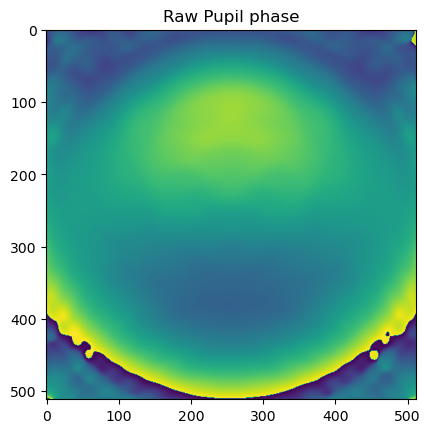

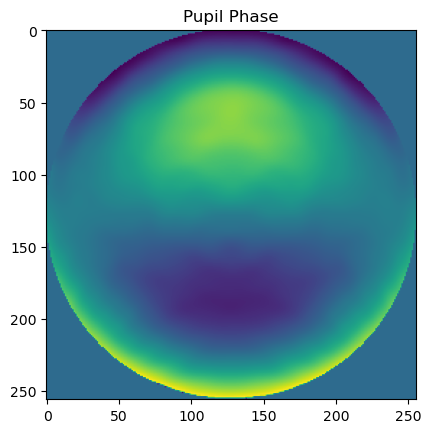

P2V error of pupil phase: 4.660913419095905
(512, 512)


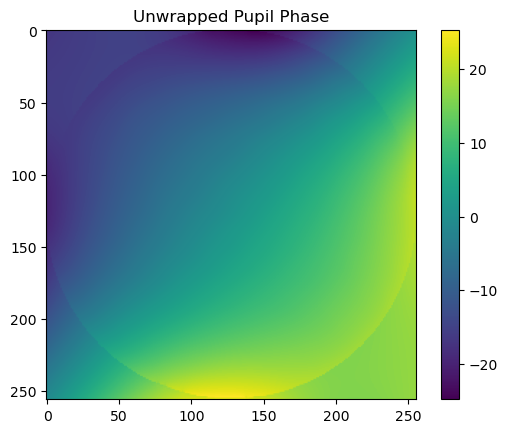

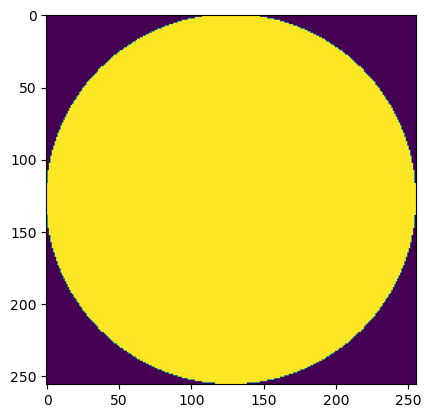

(512, 512)


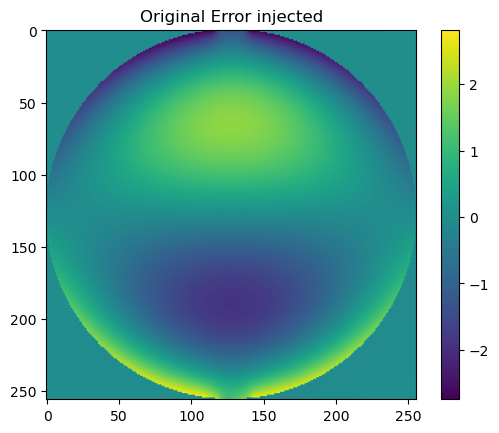

P2V of Original injected error: 5.616701452678232


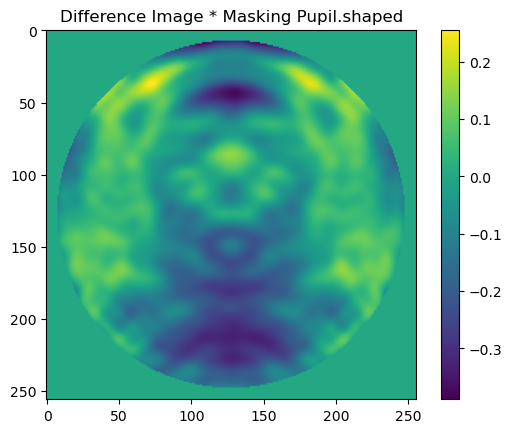

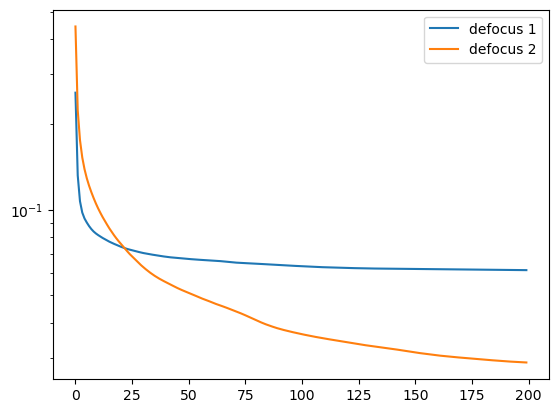

Median error in nanometers: -3.494439391423428 nm
RMS error of Check_error_region:13.306653009280714 Nanometers
RMS error of check_error_region: 0.1286279487317686 radians
F-number: 49.41
Scale: -10, Defocus distance: 69.9745 mm
Scale: 5, Defocus distance: 34.9873 mm
Defocus distances (mm): 69.97454194826209
(512, 512)
50.18228166488771
{'defocus_distances_mm': OldStyleField(69.97454195)}


In [6]:
scales=(-10,5)
test_ab_scale= 1
results = run_focus_diverse_phase_retrieval_v2(scales, test_ab_scale)
results_mm =run_focus_diverse_phase_retrieval_with_units(scales, test_ab_scale)
unwrapped_pup_phase= phase_unwrap_2d(results['pupil_phase'])
p2v_unwrapped= np.max(unwrapped_pup_phase) - np.min(unwrapped_pup_phase)
print(p2v_unwrapped)
print(results_mm)



Scale -10: P2V error: 34.636787511710644 rad, 5.512615945312379 waves, defocus distance: -69974.54194826208 microns
Scale 10: P2V error: 34.636787511710644 rad, 5.512615945312379 waves, defocus distance: 69974.54194826208 microns
Distance List: [OldStyleField(-69974.54194826), OldStyleField(69974.54194826)]
(1024, 1024)


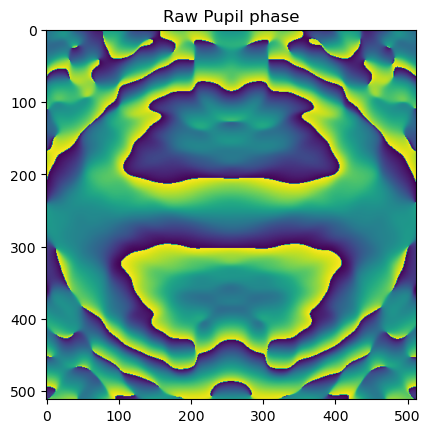

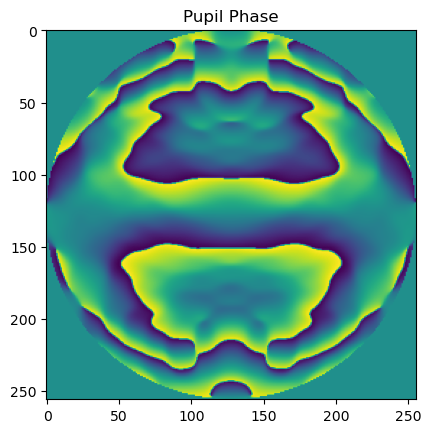

P2V error of pupil phase: 6.1624305661828185
(512, 512)


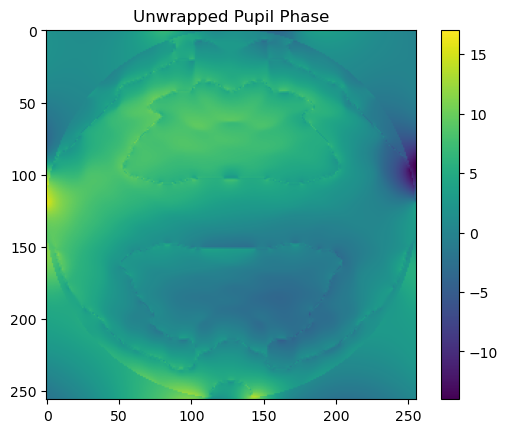


(512, 512)


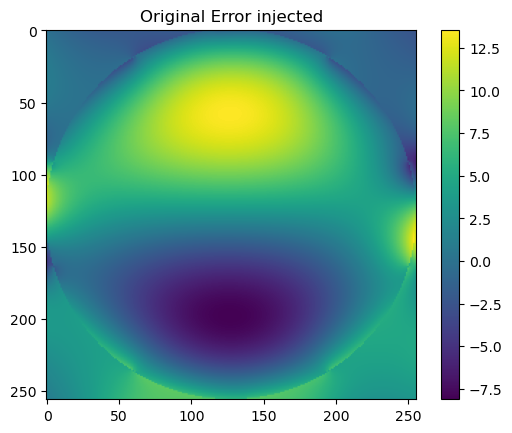

P2V of Original injected error: 6.281747027750063


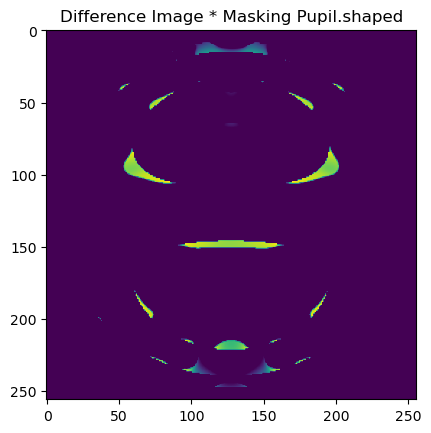

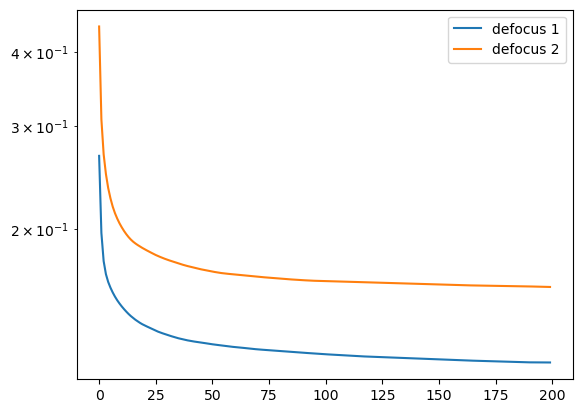

Median error in nanometers: 8.273688095205355 nm
RMS error:171.6802756987785 Nanometers
RMS error: 1.659536901235547 radians
(512, 512)
31.084939550042545


In [14]:
scales=(-10,10)
test_ab_scale= 4
results = run_focus_diverse_phase_retrieval_v2(scales, test_ab_scale)
unwrapped_pup_phase= phase_unwrap_2d(results['pupil_phase'])
p2v_unwrapped= np.max(unwrapped_pup_phase) - np.min(unwrapped_pup_phase)
print(f'Unwrapped Pupil P2V:{p2v_unwrapped}')

Scale -10: P2V error: 34.636787511710644 rad, 5.512615945312379 waves, defocus distance: -69974.54194826208 microns
Scale 10: P2V error: 34.636787511710644 rad, 5.512615945312379 waves, defocus distance: 69974.54194826208 microns
Distance List: [OldStyleField(-69974.54194826), OldStyleField(69974.54194826)]
(1024, 1024)


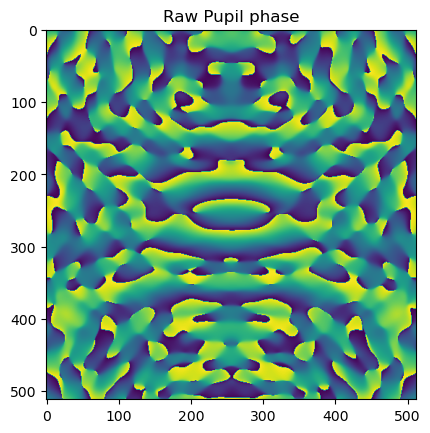

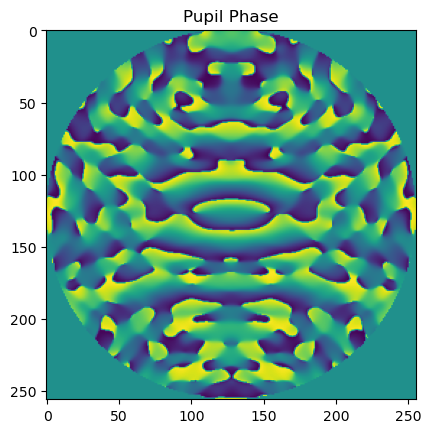

P2V error of pupil phase: 6.204694204551409
(512, 512)


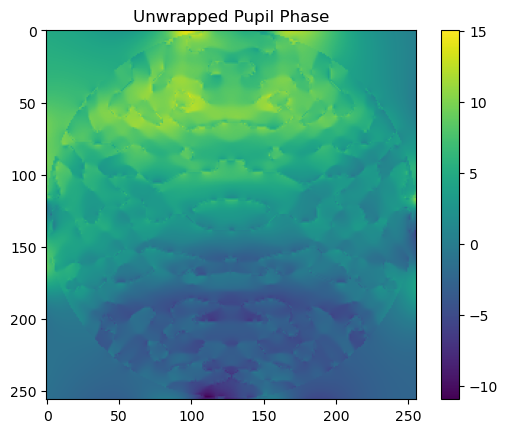


(512, 512)


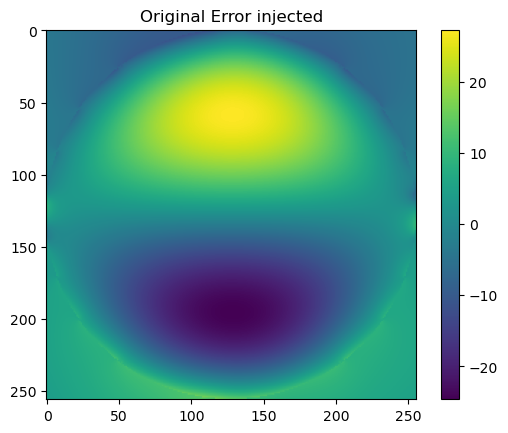

P2V of Original injected error: 6.282136102404634


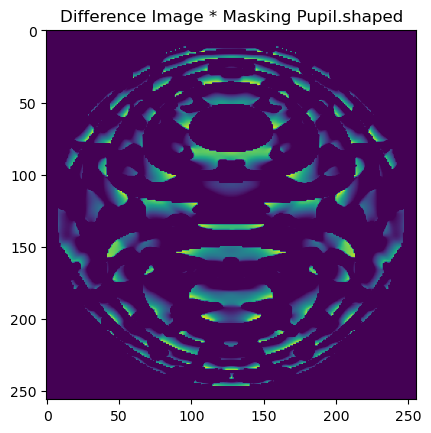

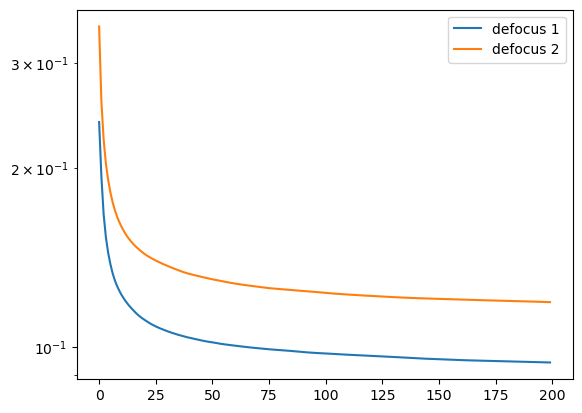

Median error in nanometers: -3.6908204513581135 nm
RMS error:181.3788340217789 Nanometers
RMS error: 1.7532874230138553 radians
(512, 512)
25.999694601171093


In [15]:
scales=(-10,10)
test_ab_scale= 10
results = run_focus_diverse_phase_retrieval_v2(scales, test_ab_scale)
unwrapped_pup_phase= phase_unwrap_2d(results['pupil_phase'])
p2v_unwrapped= np.max(unwrapped_pup_phase) - np.min(unwrapped_pup_phase)
print(p2v_unwrapped)

In [13]:
nonzero_grid=grid[grid>0]
std_dev=np.std(grid[grid>0])
print(std_dev)
median=np.median(nonzero_grid)
print(median)

0.04866240834155003
0.48353815601576705


In [15]:
plt.imshow(grid.transpose(), extent=(-10,10,-10,10), origin='lower',vmin=median-(2*std_dev), vmax=median+2*std_dev)
plt.colorbar()  # Add color bar to show the scale of rms values
plt.xlabel('X')
plt.ylabel('Y')
plt.title('RMS Error Grid, Processing, Injected error: 4.212526089508674')
plt.savefig('Nonzero_RMS_Error_plot_-10--7.5_7.5-10_100runs.png')
plt.clf()

# given some_array of data
#pull values from heatmap that look decent , run against abberation greater than 2pi



<Figure size 640x480 with 0 Axes>

In [4]:
np.save('corrected_rms_error_-10--7.5_7.5-10_.75_100runs_processing.npy', grid)


Scale -10: P2V error: 34.636787511710644 rad, 5.512615945312379 waves, defocus distance: -69974.54194826208 microns
Scale 10: P2V error: 34.636787511710644 rad, 5.512615945312379 waves, defocus distance: 69974.54194826208 microns
Distance List: [OldStyleField(-69974.54194826), OldStyleField(69974.54194826)]
(1024, 1024)


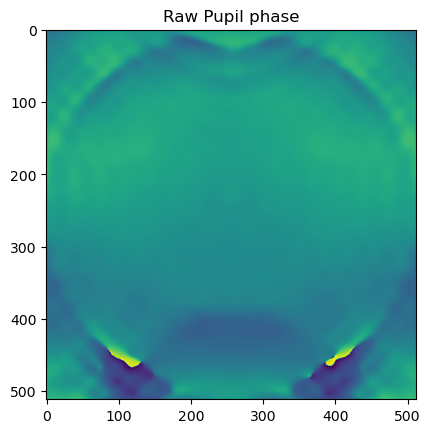

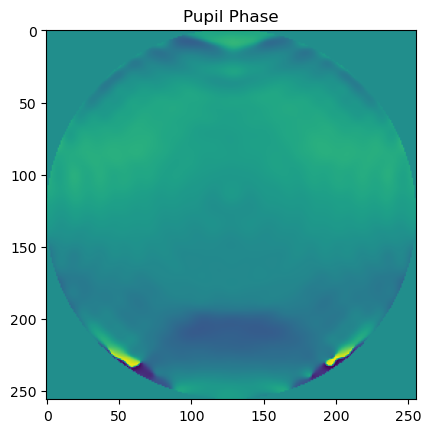

P2V error of pupil phase: 5.983284647942904
(512, 512)


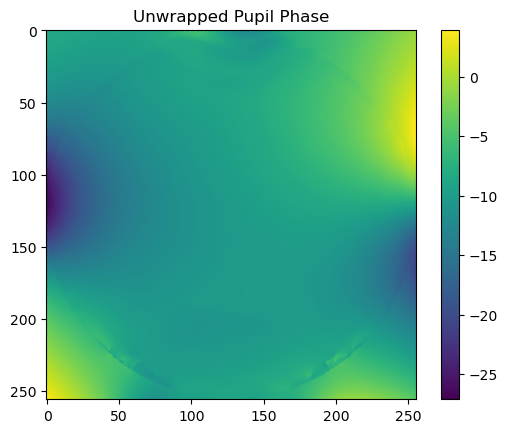

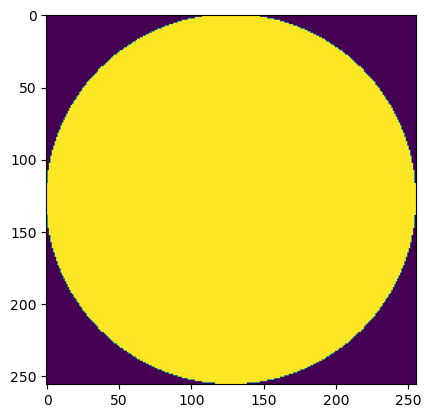

(512, 512)


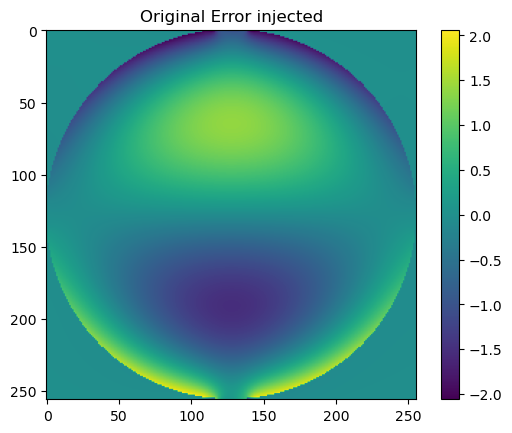

P2V of Original injected error: 4.212526089508674


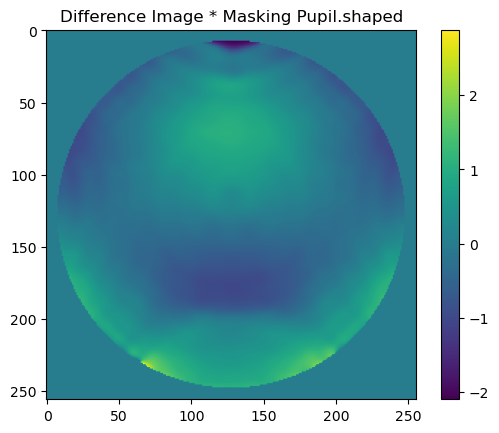

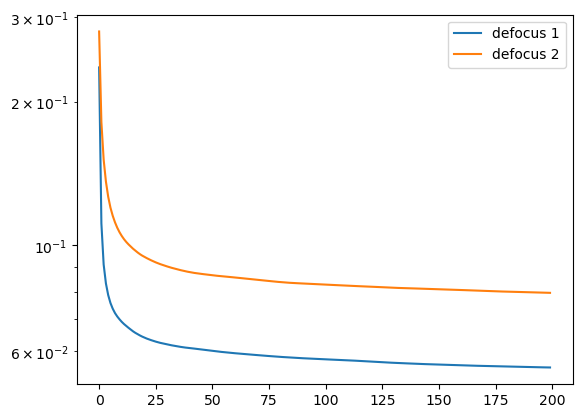

Median error in nanometers: -2.290981667192452 nm


In [29]:
for i in range(1):
    scales=(-10,10)
    test_ab_scale=0.75
    # Define constants for this run
    pupil_size = 10.12e-3
    small_pupil_size = 9.5e-3 
    focal_length = 500e-3
    wavelength = 650e-9
    grid_size = 256
    q = 16
    num_airy = 16
    f = focal_length
    D = pupil_size
    dx_list = [2.0071] * len(scales)

    # Set up pupil and focal grids
    pupil_grid = make_pupil_grid(256, pupil_size)
    focal_grid = make_focal_grid(q=q, num_airy=num_airy, pupil_diameter=pupil_size, focal_length=focal_length, reference_wavelength=wavelength)

    # Setup telescope and masking apertures
    aperture = make_circular_aperture(pupil_size)
    telescope_pupil = aperture(pupil_grid)
    small_aperture = make_circular_aperture(small_pupil_size)
    masking_pupil = small_aperture(pupil_grid)

    # Create initial wavefront
    wavefront = Wavefront(telescope_pupil, wavelength=wavelength)
    prop_p2f = FraunhoferPropagator(pupil_grid, focal_grid, focal_length=focal_length)
    pupil_image = wavefront.copy()

    # Generate Zernike polynomials for test aberrations and defocus
    influence_functions = make_zernike_basis(256, pupil_size, pupil_grid)
    test_ab = test_ab_scale * influence_functions[6]
    example_defocus = influence_functions[3].shaped

    # Generate PSFs and defocus distances for different scales
    psf_list, distance_list, dx_list = generate_defocus_lists(example_defocus, scales, f, D, test_ab, telescope_pupil, wavelength)
    #for i, psf in enumerate(psf_list):
        #print(f"PSF {i} shape: {psf.shape}, max: {np.max(psf)}, min: {np.min(psf)}")
    
    # Output the lists
    #print("PSF List", psf_list)
    print("Distance List:", distance_list)
    #print("DX List:", dx_list)
    #defocus_images(psf_list)
    
    # Initialize the focus diverse phase retrieval process
    mp = FocusDiversePhaseRetrieval(psf_list,650e-3, dx_list, distance_list,phase_guess=np.zeros_like(psf_list[0]))
    for i in range(200):
        psf00 = mp.step() 
    # Configure instrument
    seal_params = {'image_dx': 2.0071, # 
               'efl': focal_length*1e3, # SEAL effective focal length, mm
               'wavelength': 0.65, # SEAL center wavelength, microns
                'pupil_size': pupil_size*1e3, # Keck entrance pupil diameter
                    }
    conf = InstrumentConfiguration(seal_params)
    
    #Plot the Phase in focal plane
    #plt.imshow(np.angle(psf00))
    #plt.title(f'Phase in focal plane')
    #plt.show()
    
    #Unwrap the phase and Plot unwrapped phase
    unwrapped_psf00 = phase_unwrap_2d(np.angle(psf00))
    #plt.imshow(unwrapped_psf00)
    #plt.colorbar()
    #plt.title("Unwrapped Phase of PSF00")
    #plt.show()
                                      
    #Retrieve raw pupil phase
    raw_pupil_phase = np.angle(mft_rev(psf00, conf))
    plt.imshow(raw_pupil_phase)
    plt.title(f'Raw Pupil phase')
    plt.show()
    
    #Resize and visualize the pupil phase
    pupil_phase = resize(raw_pupil_phase, (256, 256)) * telescope_pupil.shaped
    plt.imshow(pupil_phase)
    plt.title(f'Pupil Phase')
    plt.show()
    print(f'P2V error of pupil phase: {np.max(pupil_phase) - np.min(pupil_phase)}')
                             
    #Unwrap the pupil phase, thought it could be interesting
    unwrapped_pupil_phase = phase_unwrap_2d(pupil_phase)
    plt.imshow(unwrapped_pupil_phase)  # Unwrapped pupil plane phase
    plt.colorbar()
    plt.title("Unwrapped Pupil Phase")
    plt.show()
    print()

    # Plot the intensity for PSF (Focal Plane), debugging to ensure that we at least have a psf00
    intensity_psf00 = np.abs(psf00)**2
    #plt.imshow(intensity_psf00)  # Intensity in focal plane
    #plt.colorbar()
    #plt.title("Intensity of PSF00 (Focal Plane)")
    #plt.show()
    
    #Debugging to ensure we have a decent pupil
    plt.imshow(telescope_pupil.shaped)
    plt.show()
    plt.title(f'Telescope_pupil.shaped')
    
    #Comparing to Original Error
    pupil_image.electric_field = np.exp(complex(0, 1)*telescope_pupil*(test_ab))
    plt.imshow(phase_unwrap_2d(pupil_image.phase.shaped))
    plt.colorbar()
    plt.title(f'Original Error injected')
    plt.show()
    print(f'P2V of Original injected error: {np.max(pupil_image.phase.shaped) - np.min(pupil_image.phase.shaped)}')

    # Subtract median and calculate difference image
    med_subtracted = pupil_phase - np.median(pupil_phase[np.array(masking_pupil.shaped, dtype=bool)])
    difference_image = pupil_image.phase.shaped - med_subtracted#Masking pupil
    plt.imshow(difference_image * masking_pupil.shaped)
    plt.colorbar()
    plt.title(f'Difference Image * Masking Pupil.shaped')
    plt.show()
    
    #Graphing the Cost Functions, make it iterative, for i in range len[mp.cost_func]
    for i in range(len(mp.cost_functions)):
        plt.semilogy(mp.cost_functions[i], label=f'defocus {i+1}')
        
    plt.legend()
    plt.show()
    #plt.semilogy(mp.cost_functions[0], label='defocus 1', color='cyan')
    #plt.semilogy(mp.cost_functions[1], label='defocus 2', color='grey')
    #Calculate median error
    check_error_region = (pupil_image.phase.shaped - med_subtracted)[np.array(masking_pupil.shaped, dtype=bool)]
    nm_med = phase_to_m(np.median(check_error_region), 650e-9) * 1e9
    print(f'Median error in nanometers: {nm_med} nm')

    #If statement to shape the telescope pupil
    if telescope_pupil.ndim == 1:
        telescope_pupil = telescope_pupil.reshape(pupil_phase.shape)
    

    #Calculate RMS error ; convert to nano
    rms_error = np.sqrt(np.mean((check_error_region) ** 2))
    rms_nm= phase_to_m(rms_error, 650e-9)*1e9

In [31]:
rms_error
rms_nm

OldStyleField(57.5363456)

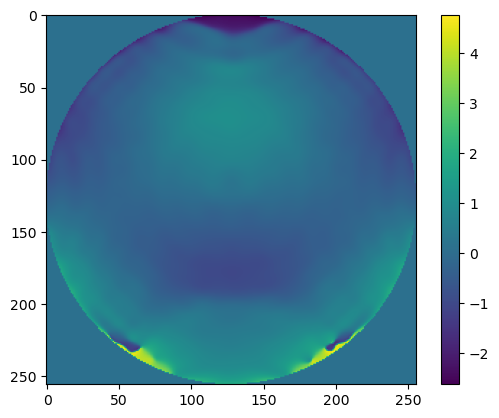

In [28]:
plt.imshow(difference_image)
plt.colorbar()